## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange: 

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

## Import Statements

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Exploration

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [4]:
df = pd.read_csv('QueryResults.csv', names=['DATE', 'TAG', 'POSTS'], header=0)

**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [5]:
df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,c,82
3,2008-08-01 00:00:00,c#,503
4,2008-08-01 00:00:00,c++,164


In [6]:
df.tail()

,DATE,TAG,POSTS
2980,2026-06-01 00:00:00,php,19
2981,2026-06-01 00:00:00,python,146
2982,2026-06-01 00:00:00,r,27
2983,2026-06-01 00:00:00,ruby,1
2984,2026-06-01 00:00:00,swift,28


**Challenge:** Check how many rows and how many columns there are. 
What are the dimensions of the dataframe?

In [7]:
df.shape

(2985, 3)

**Challenge**: Count the number of entries in each column of the dataframe

In [8]:
df.count()

DATE     2985
TAG      2985
POSTS    2985
dtype: int64

**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [9]:
df.groupby('TAG').sum()

,DATE,POSTS
TAG,,
assembly,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,45071
c,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,407791
c#,2008-07-01 00:00:002008-08-01 00:00:002008-09-...,1621591
c++,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,813714
delphi,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,52526
go,2009-11-01 00:00:002009-12-01 00:00:002010-01-...,74421
java,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,1914294
javascript,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,2521755
perl,2008-08-01 00:00:002008-09-01 00:00:002008-10-...,68279


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry? 


In [10]:
grouped_df = df.groupby('TAG').count()
grouped_df

,DATE,POSTS
TAG,,
assembly,215,215
c,215,215
c#,216,216
c++,215,215
delphi,215,215
go,200,200
java,215,215
javascript,215,215
perl,215,215


In [11]:
grouped_df.idxmin()

DATE     go
POSTS    go
dtype: str

## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [12]:
df['DATE'][1]

'2008-08-01 00:00:00'

In [13]:
df.DATE[1]

'2008-08-01 00:00:00'

In [14]:
type(df['DATE'][1])

str

In [15]:
print(pd.to_datetime(df['DATE'][1]))
type(pd.to_datetime(df['DATE'][1]))

2008-08-01 00:00:00


pandas.Timestamp

In [16]:
pd.to_datetime(df['DATE'])

0      2008-07-01
1      2008-08-01
2      2008-08-01
3      2008-08-01
4      2008-08-01
          ...    
2980   2026-06-01
2981   2026-06-01
2982   2026-06-01
2983   2026-06-01
2984   2026-06-01
Name: DATE, Length: 2985, dtype: datetime64[us]

## Data Manipulation



In [17]:
test_df = pd.DataFrame({'Age': ['Young', 'Young', 'Young', 'Young', 'Old', 'Old', 'Old', 'Old'],
                        'Actor': ['Jack', 'Arnold', 'Keanu', 'Sylvester', 'Jack', 'Arnold', 'Keanu', 'Sylvester'],
                        'Power': [100, 80, 25, 50, 99, 75, 5, 30]})
test_df

,Age,Actor,Power
0,Young,Jack,100
1,Young,Arnold,80
2,Young,Keanu,25
3,Young,Sylvester,50
4,Old,Jack,99
5,Old,Arnold,75
6,Old,Keanu,5
7,Old,Sylvester,30


In [18]:
# The index are the categories for the rows.
# The columns are the categories for the columns.
# And the values are what you want in the new cells. 
pivoted_df = test_df.pivot(index='Age', columns='Actor', values='Power')
pivoted_df

Actor,Arnold,Jack,Keanu,Sylvester
Age,,,,
Old,75,99,5,30
Young,80,100,25,50


**Mini-Challenge**

Can you pivot the df DataFrame so that each row is a date and each column is a programming language? Store the result under a variable called reshaped_df. 

In [19]:
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')
reshaped_df

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01 00:00:00,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01 00:00:00,8.0,82.0,503.0,164.0,13.0,NaN,220.0,160.0,28.0,157.0,119.0,NaN,68.0,NaN
2008-09-01 00:00:00,28.0,320.0,1636.0,749.0,104.0,NaN,1119.0,629.0,128.0,471.0,533.0,6.0,285.0,NaN
2008-10-01 00:00:00,16.0,302.0,1982.0,804.0,112.0,NaN,1142.0,721.0,128.0,603.0,504.0,NaN,245.0,NaN
2008-11-01 00:00:00,16.0,257.0,1727.0,733.0,139.0,NaN,951.0,581.0,97.0,497.0,446.0,1.0,154.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-01 00:00:00,11.0,57.0,136.0,122.0,17.0,9.0,110.0,83.0,7.0,33.0,260.0,79.0,3.0,66.0
2026-03-01 00:00:00,15.0,62.0,96.0,113.0,5.0,7.0,92.0,90.0,4.0,36.0,222.0,55.0,8.0,35.0
2026-04-01 00:00:00,12.0,43.0,89.0,81.0,4.0,4.0,75.0,86.0,7.0,21.0,166.0,66.0,1.0,29.0


Using df.pivot_table allows you to use some updated arguments. for instance, you can use
```python
  reshaped_df = df.pivot_table(index='Date', columns='Tag', values='Posts', fill_value=0)
```
to fill in missing values, and returning 0 instead of NaN.

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot_table.html

**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [20]:
reshaped_df.shape

(216, 14)

In [21]:
reshaped_df.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01 00:00:00,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01 00:00:00,8.0,82.0,503.0,164.0,13.0,NaN,220.0,160.0,28.0,157.0,119.0,NaN,68.0,NaN
2008-09-01 00:00:00,28.0,320.0,1636.0,749.0,104.0,NaN,1119.0,629.0,128.0,471.0,533.0,6.0,285.0,NaN
2008-10-01 00:00:00,16.0,302.0,1982.0,804.0,112.0,NaN,1142.0,721.0,128.0,603.0,504.0,NaN,245.0,NaN
2008-11-01 00:00:00,16.0,257.0,1727.0,733.0,139.0,NaN,951.0,581.0,97.0,497.0,446.0,1.0,154.0,NaN


In [22]:
reshaped_df.columns

Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='str', name='TAG')

**Challenge**: Count the number of entries per programming language. Why might the number of entries be different? 

In [23]:
reshaped_df.count()

TAG
assembly      215
c             215
c#            216
c++           215
delphi        215
go            200
java          215
javascript    215
perl          215
php           215
python        215
r             213
ruby          215
swift         206
dtype: int64

The `.count()` method excludes NaN values. When we pivoted the DataFrame the NaN values were inserted when there were no posts for a language in that month (e.g., Swift in July, 2008).

In this case, we don't want to drop the rows that have a NaN value. Instead, we want to substitute the number 0 for each NaN value in the DataFrame. We can do this with the `.fillna()` method.

In [24]:
reshaped_df.fillna(0, inplace=True) 

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01 00:00:00,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01 00:00:00,8.0,82.0,503.0,164.0,13.0,0.0,220.0,160.0,28.0,157.0,119.0,0.0,68.0,0.0
2008-09-01 00:00:00,28.0,320.0,1636.0,749.0,104.0,0.0,1119.0,629.0,128.0,471.0,533.0,6.0,285.0,0.0
2008-10-01 00:00:00,16.0,302.0,1982.0,804.0,112.0,0.0,1142.0,721.0,128.0,603.0,504.0,0.0,245.0,0.0
2008-11-01 00:00:00,16.0,257.0,1727.0,733.0,139.0,0.0,951.0,581.0,97.0,497.0,446.0,1.0,154.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-01 00:00:00,11.0,57.0,136.0,122.0,17.0,9.0,110.0,83.0,7.0,33.0,260.0,79.0,3.0,66.0
2026-03-01 00:00:00,15.0,62.0,96.0,113.0,5.0,7.0,92.0,90.0,4.0,36.0,222.0,55.0,8.0,35.0
2026-04-01 00:00:00,12.0,43.0,89.0,81.0,4.0,4.0,75.0,86.0,7.0,21.0,166.0,66.0,1.0,29.0


The `inplace` argument means that we are updating reshaped_df. Without this argument we would have to write something like this:
```python
reshaped_df = reshaped_df.fillna(0) 
```

We can also check if there are any NaN values left in the entire DataFrame with this line:

In [25]:
reshaped_df.isna().values.any()

np.False_

Here we are using the `.isna()` method that we've used before, but we're chaining two more things: the `values` attribute and the `any()` method. This means we don't have to search through the entire DataFrame to spot if `.isna()` is True.

## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

DatetimeIndex(['2008-07-01', '2008-08-01', '2008-09-01', '2008-10-01',
               '2008-11-01', '2008-12-01', '2009-01-01', '2009-02-01',
               '2009-03-01', '2009-04-01',
               ...
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
               '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01'],
              dtype='datetime64[us]', name='DATE', length=216, freq=None)

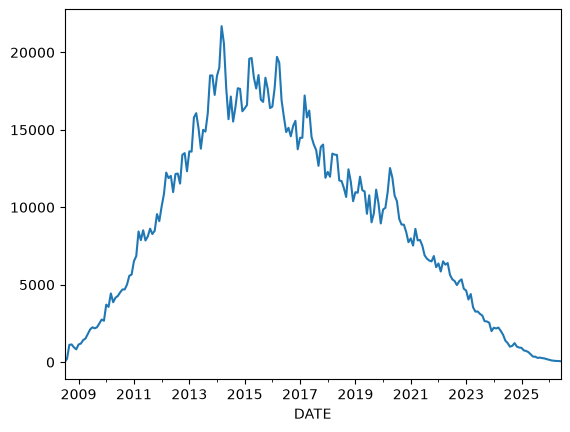

In [39]:
reshaped_df.index = pd.to_datetime(reshaped_df.index)
reshaped_df['java'].plot()
reshaped_df.index

All you need to do is supply the values for the horizontal axis (the x-values) and the vertical axis (the y-values) for the chart. The x-values are our dates and the y-values are the number of posts. We can supply these values to the `.plot()` function by position like so:
```python
plt.plot(reshaped_df.index, reshaped_df.java)
```
or like so if you prefer the square bracket notation.
```python
plt.plot(reshaped_df.index, reshaped_df['java'])
```

**Styling the Chart**
Let's look at a couple of methods that will help us style our chart:

`.figure()` - allows us to resize our chart

`.xticks()` - configures our x-axis

`.yticks()` - configures our y-axis

`.xlabel()` - add text to the x-axis

`.ylabel()` - add text to the y-axis

`.ylim()` - allows us to set a lower and upper bound

To make our chart larger we can provide a width (16) and a height (10) as the `figsize` of the figure.
```python
plt.figure(figsize=(16,10)) 
plt.plot(reshaped_df.index, reshaped_df.java)
```

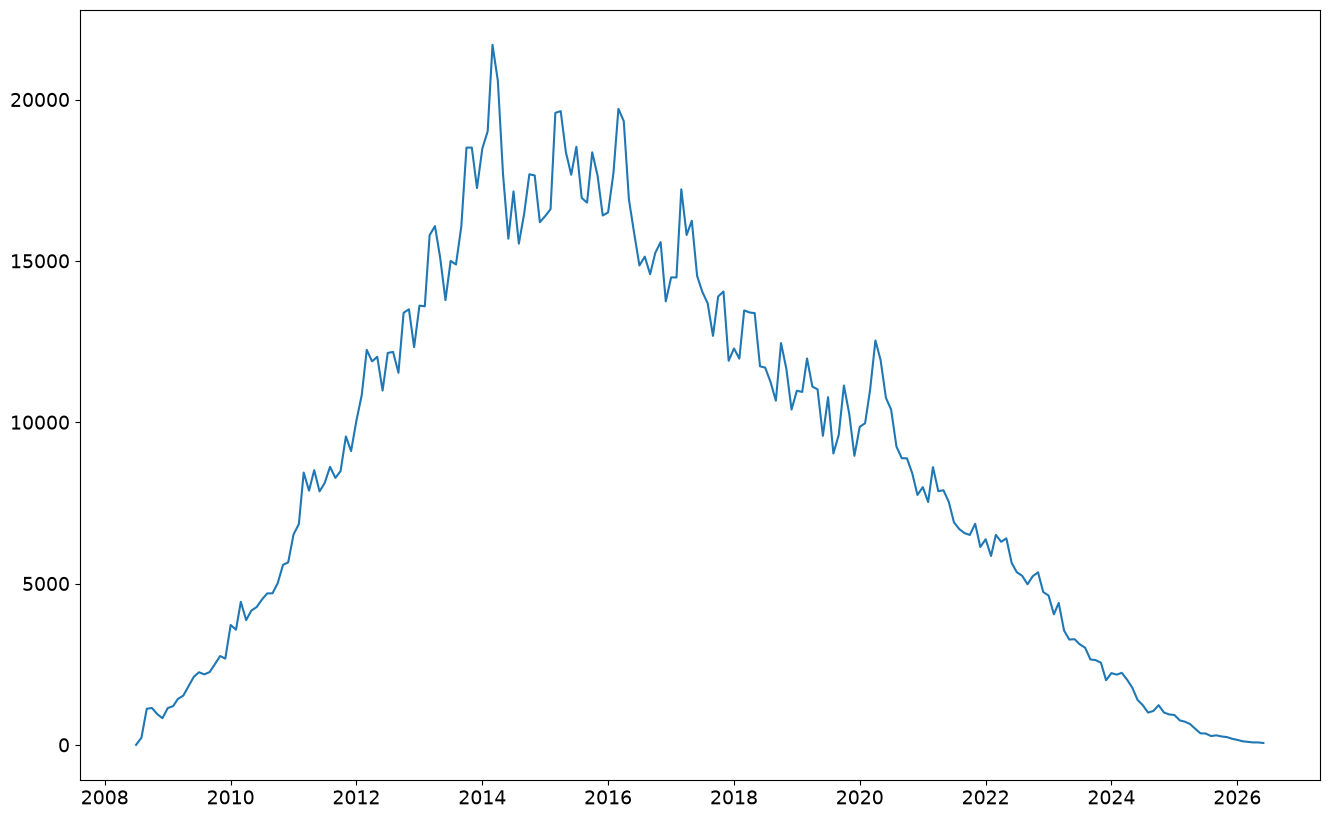

In [40]:
plt.figure(figsize=(16,10)) 
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.plot(reshaped_df.index, reshaped_df.java)

Now we can add labels. Also, we're never going to get less than 0 posts, so let's set a lower limit of 0 for the y-axis with `.ylim()`.
```python
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
```

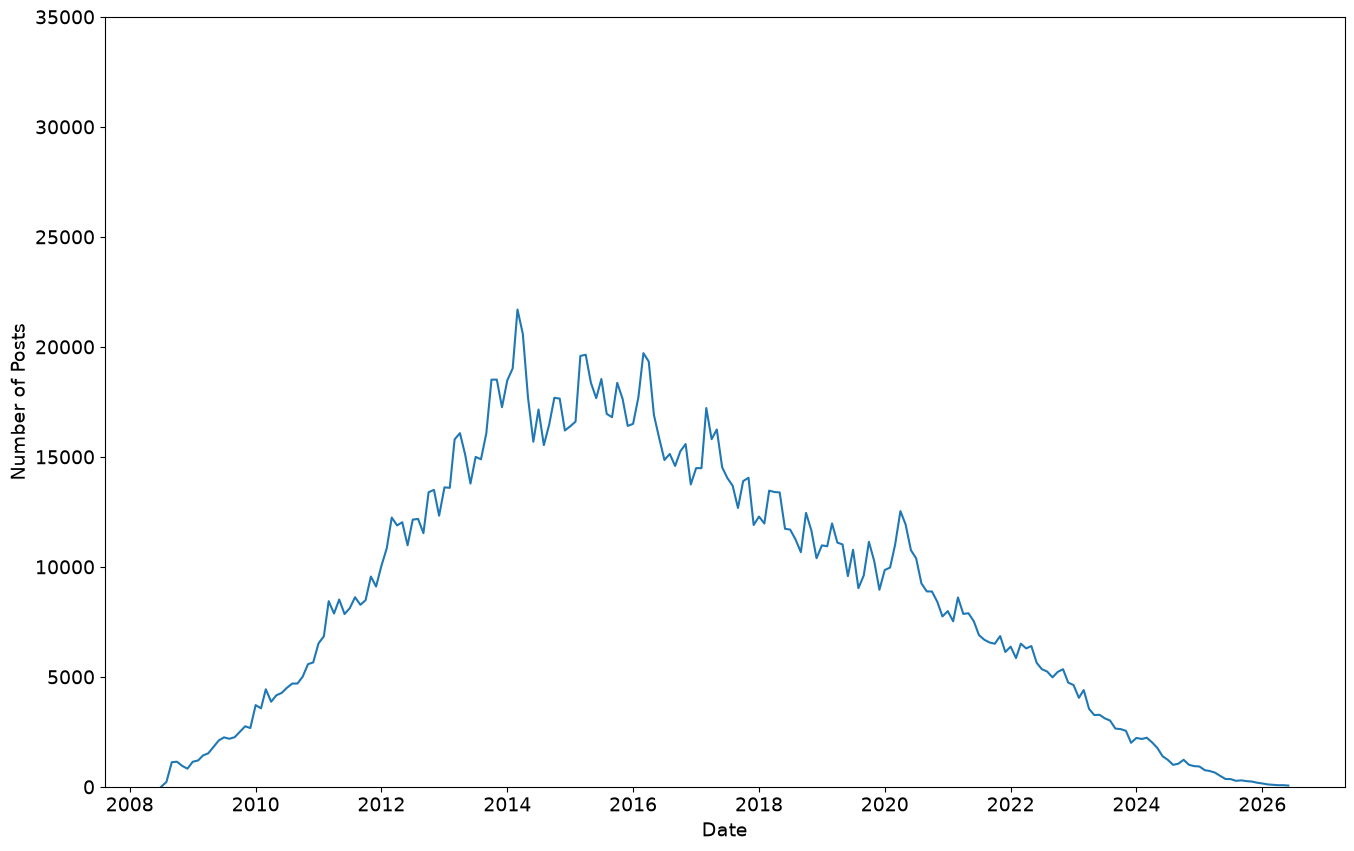

In [43]:
plt.figure(figsize=(16,10)) 
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
plt.plot(reshaped_df.index, reshaped_df.java)

**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

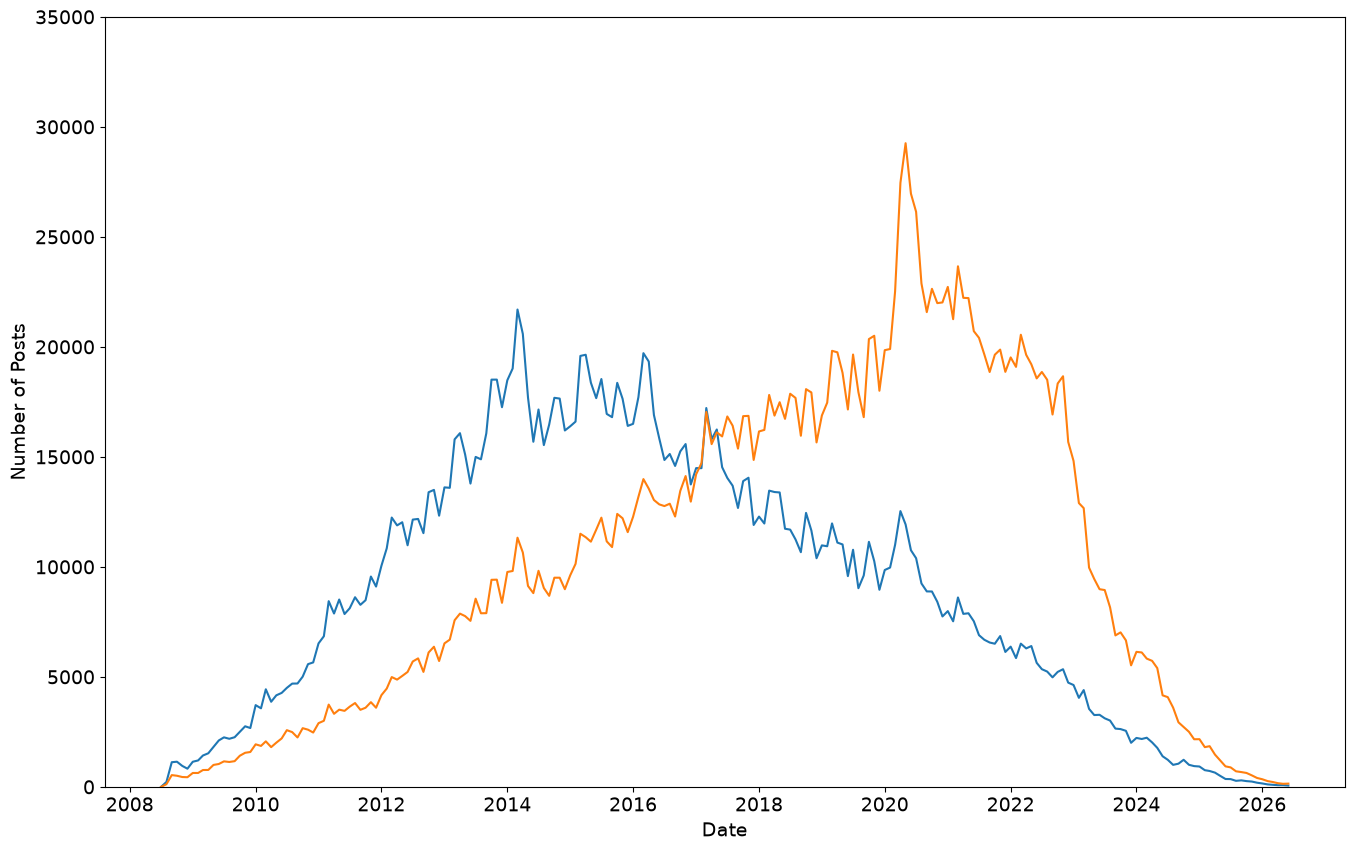

In [45]:
plt.figure(figsize=(16,10)) # make chart larger
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
plt.plot(reshaped_df.index, reshaped_df.java, reshaped_df.index, reshaped_df.python)

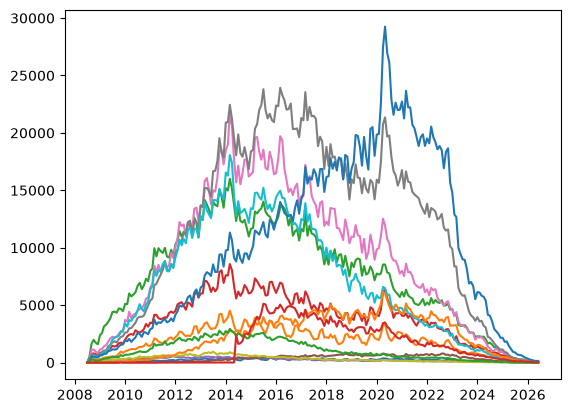

In [46]:
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index, reshaped_df[column])

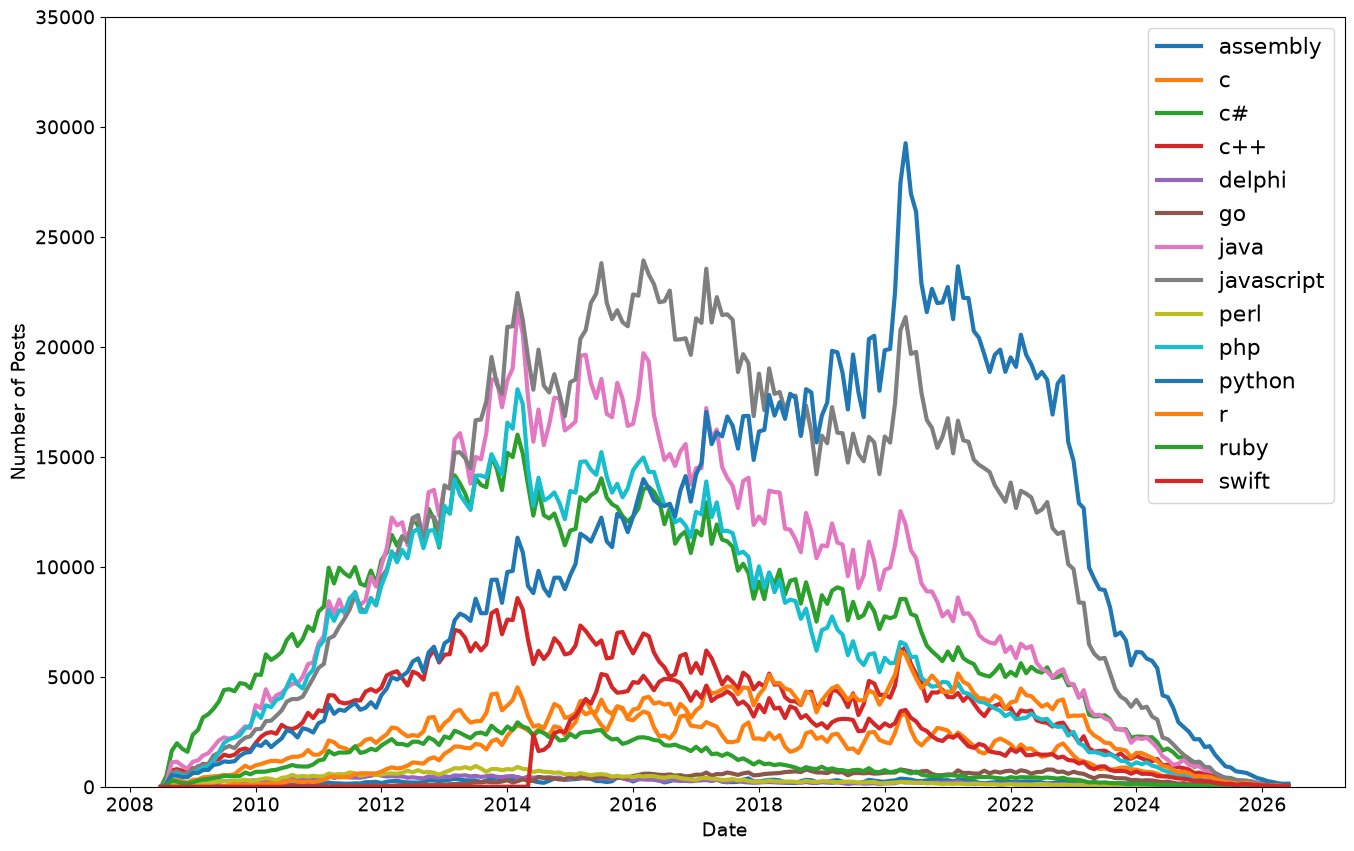

In [49]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
 
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index, reshaped_df[column], linewidth=3, label=reshaped_df[column].name)

plt.legend(fontsize=16) 

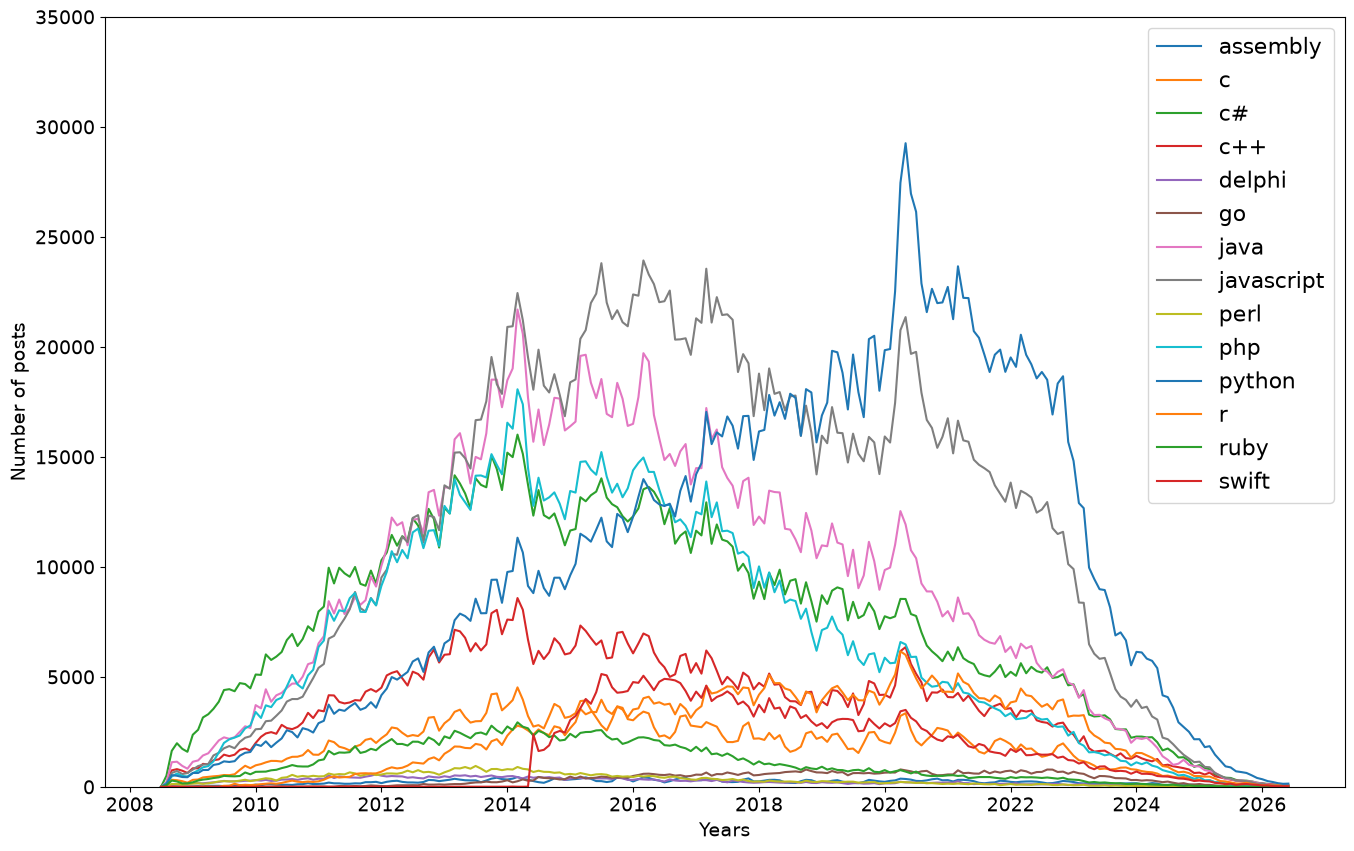

In [50]:
# Without for loop
# Bigger plot space
plt.figure(figsize=(16, 10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
 
# Add labels
plt.xlabel('Years', fontsize=14)
plt.ylabel('Number of posts', fontsize=14)
plt.ylim(bottom=0, top=35000)
 
# Plot all
plt.plot(reshaped_df.index, reshaped_df)
 
# Add legends
plt.legend(reshaped_df.columns,fontsize=16)

# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html). 

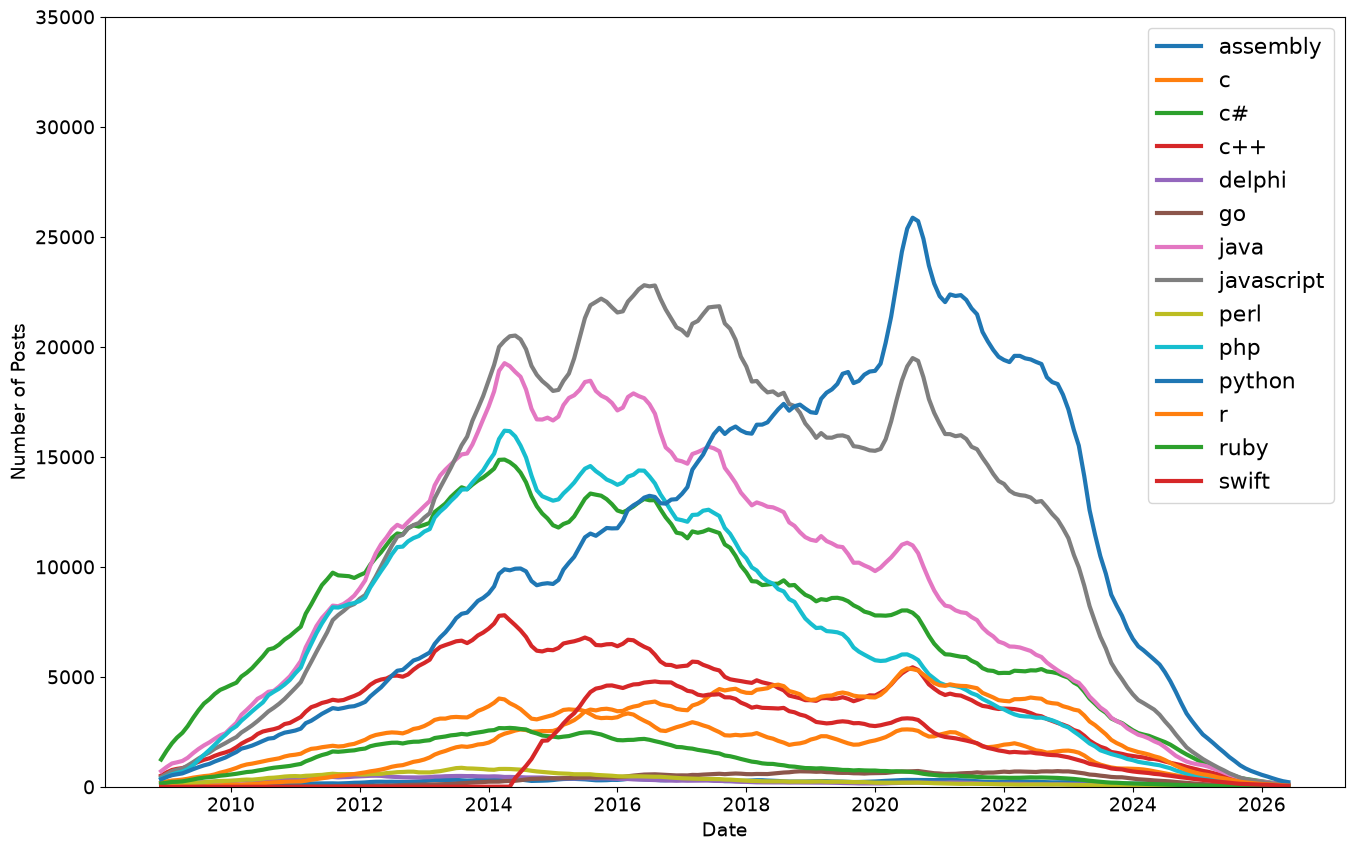

In [54]:
# The window is number of observations that are averaged
roll_df = reshaped_df.rolling(window=6).mean()
 
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)
 
# plot the roll_df instead
for column in roll_df.columns:
    plt.plot(roll_df.index, roll_df[column], 
             linewidth=3, label=roll_df[column].name)
 
plt.legend(fontsize=16)

Think of `rolling()` as making a small moving window over your data, and mean() as taking the average inside that window.

Example with monthly posts:

`rolling(window=6)` = “look at 6 months at a time”
`.mean()` = “for each 6-month window, compute the average”
So:
```python
df['python'].rolling(6).mean()
```
means:

- month 1-5: not enough data yet for 6 months, so usually NaN
- month 6: average of months 1..6
- month 7: average of months 2..7
- month 8: average of months 3..8
- and so on

Why use it:

- it smooths noisy up/down spikes
- helps you see the overall trend more clearly

In plain language: it’s a “moving average.”

Question 1: Looking at the data, what was the most popular programming language from 2008 to 2012 by the number of posts?

In [58]:
df.DATE = pd.to_datetime(df.DATE)
df

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,c,82
3,2008-08-01,c#,503
4,2008-08-01,c++,164
...,...,...,...
2980,2026-06-01,php,19
2981,2026-06-01,python,146
2982,2026-06-01,r,27
2983,2026-06-01,ruby,1


In [91]:
filtered_1 = df.loc[(df.DATE >= "2008-07-01") & (df.DATE <= "2012-12-31")]
grouped_filtered_df = filtered_1.groupby('TAG')['POSTS'].sum().sort_values(ascending=False)
grouped_filtered_df

TAG
c#            377415
java          323502
php           297392
javascript    289100
c++           160730
python        147395
c              76349
ruby           59022
perl           22570
r              20716
delphi         17780
assembly        6867
go              1500
swift            161
Name: POSTS, dtype: int64

Question 2: What was the most popular programming language from 2015 to 2018?

In [92]:
dfp = df.copy()
dfp["DATE"] = pd.to_datetime(dfp["DATE"]).dt.to_period("Y")
subset = dfp.loc[(dfp["DATE"] >= "2015") & (dfp["DATE"] <= "2018")]
posts_by_tag = subset.groupby("TAG")["POSTS"].sum().sort_values(ascending=False)
posts_by_tag

TAG
javascript    970394
java          725433
python        688454
php           568302
c#            539366
c++           263033
swift         194495
r             186928
c             129760
ruby           80402
go             26407
perl           18569
assembly       14567
delphi         13647
Name: POSTS, dtype: int64

Question 3: What was the most popular programming language in 2020?

In [94]:
df_q3 = df.copy()
df_q3["DATE"] = pd.to_datetime(df_q3["DATE"]).dt.to_period("Y")
subset_q3 = dfp.loc[(dfp["DATE"] == "2020")]
posts_by_tag_q3 = subset.groupby("TAG")["POSTS"].sum().sort_values(ascending=False)
posts_by_tag_q3

TAG
python        283182
javascript    212814
java          119591
c#             87129
php            65613
r              59795
c++            57736
swift          33292
c              29384
go              7905
ruby            7431
assembly        3687
delphi          2227
perl            2144
Name: POSTS, dtype: int64